# Orthonormalization Methods in Orbital Optimization: A Comparative Study

This tutorial demonstrates the implementation and comparison of different orthonormalization methods in quantum chemical orbital optimization using the FrayedEnds package.

## Table of Contents

1. Introduction
2. Theory: Orthonormalization Methods
3. Implementation
4. Test Cases
---

## 1. Introduction <a name="introduction"></a>

In quantum chemistry calculations, maintaining orthonormality of orbitals during optimization is crucial. This tutorial explores three different approaches:

- **Symmetric Orthonormalization (Löwdin)**: Preserves symmetry but can amplify numerical errors
- **Cholesky Orthonormalization**: Numerically stable but can break symmetries
- **Mixed Orthonormalization**: Our novel approach that combines both methods

### Key Implementation Decision: Mixed Orthonormalization

We developed a mixed approach that:
1. **Groups degenerate orbitals** (same occupation number within tolerance)
2. **Applies symmetric orthonormalization within each group** to preserve symmetry
3. **Applies Cholesky orthonormalization between groups** for numerical stability

This strategy provides the best of both worlds:
- Preserves symmetry within degenerate manifolds
- Ensures numerical stability between different manifolds

## 2. Theory: Orthonormalization Methods <a name="theory"></a>

### Cholesky Orthogonalization

Cholesky orthogonalization is essentially the matrix-based variant of the classical Gram-Schmidt process. It is characterized by high efficiency but possesses specific properties regarding the symmetry of the resulting orbitals.

#### Prerequisites

To apply the Cholesky method, the overlap matrix $\mathbf{S}$ with elements $S_{ij} = \langle \phi_i | \phi_j \rangle$ must fulfill two central conditions:

1. **Hermiticity**: The matrix must be Hermitian ($\mathbf{S} = \mathbf{S}^\dagger$). For real orbitals, this corresponds to symmetry ($\mathbf{S} = \mathbf{S}^T$). This is standard in quantum chemistry.

2. **Positive Definiteness**: This is the critical point. It means that no linear dependencies may exist in the basis (all eigenvalues $> 0$).


**Numerical Stability in Application:**

In practice, starting orbitals are usually orthogonal. However, if orbitals are mixed based on Reduced Density Matrices (RDMs), two orbitals can become very similar. In this case, $\mathbf{S}$ becomes singular (the determinant approaches 0), leading to numerical errors and a breakdown of the Cholesky decomposition.

#### Structural Change of Orbitals

This is the most important difference compared to symmetric methods. The Cholesky transformation is characterized by a triangular matrix, leading to an asymmetric treatment of the orbitals. Let the input basis be fixedly ordered as $[\phi_1, \phi_2, \dots, \phi_k]$:

- **Orbital 1** ($\psi_1$): Remains almost unchanged in form and is merely normalized. No mixing with subsequent orbitals occurs.

- **Orbital 2** ($\psi_2$): Is orthogonalized against $\psi_1$. Thus, it contains components of $\phi_1$ and $\phi_2$.

- **Orbital k** ($\psi_k$): Is orthogonalized against all previous orbitals $1$ to $k-1$.


#### Physical Consequences

This hierarchy has direct effects on the localization of the wavefunctions:

- **Asymmetry**: The transformation does not treat all orbitals equally.

- **Localization**: The "first" orbitals retain their original localization (e.g., core orbitals near the nucleus).

- **Delocalization**: The "last" orbitals are often "smeared" (delocalized) because they must absorb the residuals of all previous orbitals to ensure orthogonality.

- **Order Dependency**: The physical shape of the resulting basis depends strongly on the sorting of the input array. A permutation leads to a physically different set of orthogonal orbitals.


#### Mathematical Background

The overlap matrix is factorized using Cholesky decomposition:

$$\mathbf{S} = \mathbf{L} \mathbf{L}^T$$

where $\mathbf{L}$ is a lower triangular matrix. The transformation matrix $\mathbf{X}$ acting on the orbitals is calculated as:

$$\mathbf{X} = (\mathbf{L}^{-1})^T$$

Since the inverse of a triangular matrix is also a triangular matrix, the orbitals mix only unidirectionally ("in one direction"), which explains the hierarchy described above.

**Steps:**

1. Perform Cholesky decomposition of $\mathbf{S}$ to obtain $\mathbf{L}$:

    $$\mathbf{S} = \mathbf{L}\mathbf{L}^\dagger$$

2. Calculate the transformation matrix $\mathbf{X}$ (inverse adjoint):

    $$\mathbf{X} = (\mathbf{L}^{-1})^\dagger$$

    Alternatively: Solve the corresponding linear system.

3. Apply $\mathbf{X}$ to your original basis vectors to obtain the new orthogonal vectors $|\phi'\rangle$.


---

### Symmetric / Löwdin Orthogonalization

Symmetric orthogonalization, often referred to as Löwdin orthogonalization, differs fundamentally from recursive methods like Cholesky through its holistic approach.

#### Prerequisites

Analogous to Cholesky decomposition, the overlap matrix $\mathbf{S}$ must possess the following properties:

- **Hermiticity**: $\mathbf{S} = \mathbf{S}^\dagger$

- **Positive Definiteness**: No linear dependencies may exist.


**Numerical Risks:**

A critical scenario in implementation is the generation of nearly identical orbitals. This leads to a singular matrix $\mathbf{S}$. Since the Löwdin method requires the inverse square root $\mathbf{S}^{-1/2}$, a determinant near zero leads to massive numerical instability (division by zero), similar to the Cholesky method.

#### Structural Change of Orbitals

The unique feature of Löwdin orthogonalization is the manner in which the original basis is deformed.

**Principle of Least Change:**

Mathematically, it can be shown that the Löwdin basis $\psi$ is the orthonormal basis that minimizes the sum of squared deviations from the original orbitals $\phi$. It holds that:

$$\min \sum_i \left\| \psi_i - \phi_i \right\|^2$$

This means the new orbitals remain as similar as possible to the original ones ("Least-Squares Property").

**Symmetric Treatment vs. Cholesky:**

The difference can be illustrated geometrically using two vectors enclosing an angle of $80°$ instead of the desired $90°$:

- **Cholesky**: Fixes the first vector and rotates the second by $10°$. The treatment is asymmetric.

- **Löwdin**: Rotates the first vector by $5°$ to the left and the second by $5°$ to the right. Both are treated equally.


**Preservation of Symmetry:**

If the original orbitals possess specific symmetry properties (e.g., $s, p_x, p_y, p_z$ atomic orbitals), these are preserved in the Löwdin basis. A recursive method would break this symmetry.

**Physical Consequence:**

The orbitals retain their localization. An orbital originally localized on a specific atom remains centered there after orthogonalization. It merely forms small extensions ("tails") on neighboring atoms to ensure orthogonality.

#### Mathematical Background

The transformation matrix $\mathbf{X}$ is defined as:

$$\mathbf{X} = \mathbf{S}^{-1/2}$$

Since the direct calculation of the inverse square root of a matrix is not trivial, the calculation is usually performed via complete diagonalization (eigenvalue decomposition):

1. **Diagonalization**: $\mathbf{S} = \mathbf{U} \mathbf{\Lambda} \mathbf{U}^\dagger$, where $\mathbf{\Lambda}$ is the diagonal matrix of eigenvalues.

2. **Inversion of the root**: Calculation of $\mathbf{\Lambda}^{-1/2}$ by taking the reciprocal of the square roots of the diagonal elements.

3. **Back-transformation**:

    $$\mathbf{S}^{-1/2} = \mathbf{U} \mathbf{\Lambda}^{-1/2} \mathbf{U}^\dagger$$
---

### Mixed Orthonormalization

Our implementation:
1. Group orbitals by occupation number (degeneracy)
2. Use symmetric orthonormalization within degenerate groups
3. Use Cholesky orthonormalization between groups

**Advantages**: Preserves symmetry where needed, stable overall

**Use cases**:
- Systems with symmetries (atomic systems, symmetric molecules)
- Iterative orbital optimization where new orbitals are added

## 3. Implementation <a name="implementation"></a>

### Setup and Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tequila as tq
import frayedends as fe
from ortho_test_utils import *

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Configuration
n_electrons = 4
n_orbitals = 6
econv = 1e-8  # Energy convergence threshold

### Define Test Potentials

We will test three different potential scenarios that highlight the strengths and weaknesses of each method.

In [2]:
def potential_three_peaks(x: float, y: float) -> float:
    """
    Three Gaussian peaks potential - tests handling of degenerate orbitals.
    This potential has multiple minima, leading to orbitals with similar energies.
    Good for testing symmetric orthonormalization.
    """
    a = -(3.0 + 1.0 * n_electrons)
    b = -(2.0 + 0.8 * n_electrons)
    c = -(1.0 + 0.5 * n_electrons)

    width_scale = 1.0 / np.sqrt(max(1, n_electrons * 0.5))
    alpha = 0.5 * width_scale

    # Three peaks at different positions
    r1 = np.linalg.norm(np.array([x, y]) - np.array([4.0, 0.0]))
    r2 = np.linalg.norm(np.array([x, y]) - np.array([0.0, 4.0]))
    r3 = np.linalg.norm(np.array([x, y]))

    return (a * np.exp(-alpha * r1**2) +
            b * np.exp(-alpha * r2**2) +
            c * np.exp(-alpha * r3**2))

def potential_single_peak(x: float, y: float) -> float:
    """
    Single Gaussian peak - simple test case with radial symmetry.
    Tests preservation of symmetry during optimization.
    """
    c = -1.5 * n_electrons
    width = 0.5
    width_scale = 0.15 if n_electrons > 2 else 0.5

    r = np.linalg.norm(np.array([x, y]))
    return c * np.exp(-(width * width_scale) * r**2)

def potential_coulomb(x: float, y: float) -> float:
    """
    Helium-like Coulomb potential - physically realistic test case.
    """
    r = np.linalg.norm(np.array([x, y]))
    epsilon = 1e-7
    return -n_electrons / np.sqrt(r**2 + epsilon)

### Visualize the Potentials

Let's first look at the potential energy surfaces we'll be working with.

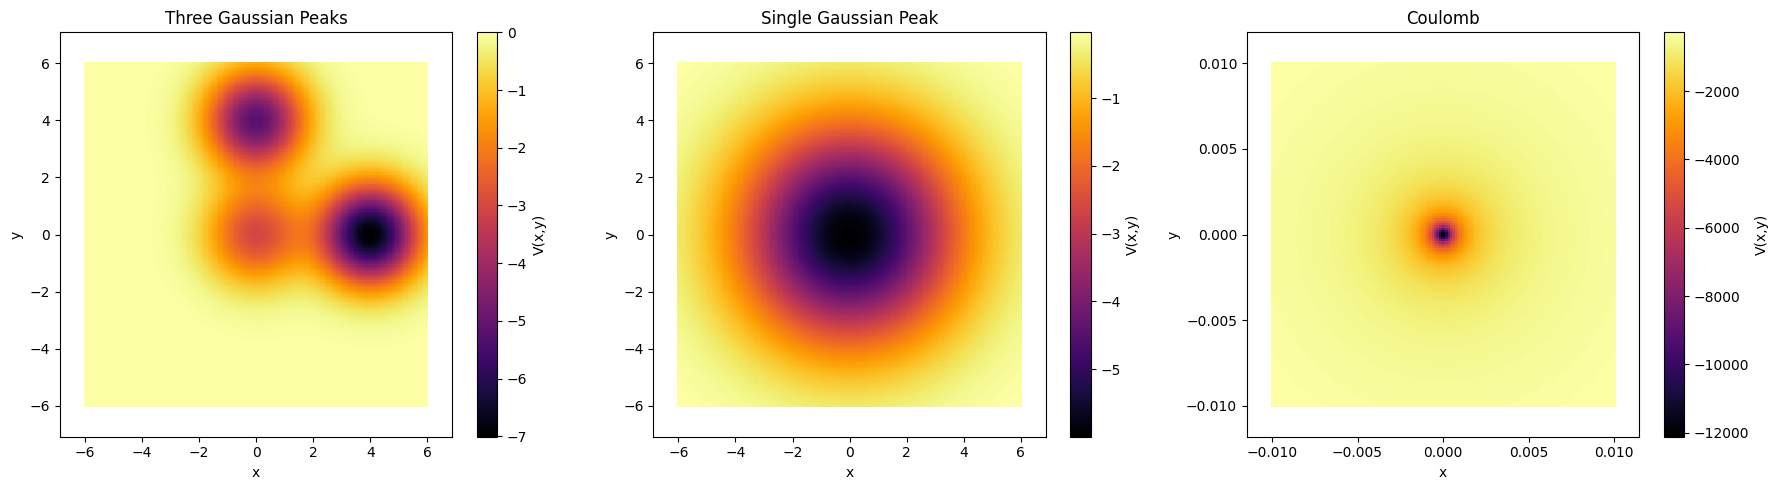

In [3]:
# Create a figure with all three potentials
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Three peaks potential
x_range = np.linspace(-6, 6, 150)
y_range = np.linspace(-6, 6, 150)
X, Y = np.meshgrid(x_range, y_range)
Z = np.zeros_like(X)
for i in range(len(x_range)):
    for j in range(len(y_range)):
        Z[i, j] = potential_three_peaks(X[i, j], Y[i, j])

im1 = axes[0].pcolormesh(X, Y, Z, shading='auto', cmap='inferno')
axes[0].set_title('Three Gaussian Peaks', fontsize=12)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].axis('equal')
plt.colorbar(im1, ax=axes[0], label='V(x,y)')

# Single peak potential
Z = np.zeros_like(X)
for i in range(len(x_range)):
    for j in range(len(y_range)):
        Z[i, j] = potential_single_peak(X[i, j], Y[i, j])

im2 = axes[1].pcolormesh(X, Y, Z, shading='auto', cmap='inferno')
axes[1].set_title('Single Gaussian Peak', fontsize=12)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].axis('equal')
plt.colorbar(im2, ax=axes[1], label='V(x,y)')

# Helium potential (smaller range)
x_range_he = np.linspace(-0.01, 0.01, 150)
y_range_he = np.linspace(-0.01, 0.01, 150)
X_he, Y_he = np.meshgrid(x_range_he, y_range_he)
Z_he = np.zeros_like(X_he)
for i in range(len(x_range_he)):
    for j in range(len(y_range_he)):
        Z_he[i, j] = potential_coulomb(X_he[i, j], Y_he[i, j])

im3 = axes[2].pcolormesh(X_he, Y_he, Z_he, shading='auto', cmap='inferno')
axes[2].set_title('Coulomb', fontsize=12)
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].axis('equal')
plt.colorbar(im3, ax=axes[2], label='V(x,y)')

plt.tight_layout()
plt.show()

### Potential Characteristics
The Three Peaks potential creates three distinct Gaussian wells of varying depths, effectively isolating electron pairs in separate localized regions. The Single Peak forms a broad, harmonic-like basin designed to hold higher energy states, while the coulomb potential presents a sharp, singular funnel characteristic.
Important to notice is that the scale of the coulomb potential is very different from the two gaussian ones.

### Main Calculation Function

This function performs the orbital optimization using a specified orthonormalization method.

In [4]:
def run_calculation(potential_func, geometry, ortho_method="mixed",
                   max_iterations=10):
    """
    Run orbital optimization with specified orthonormalization method.

    Parameters:
    -----------
    potential_func : callable
        2D potential function V(x, y)
    geometry : str
        Molecular geometry string for tequila
    ortho_method : str
        'symmetric', 'cholesky', or 'mixed'
    max_iterations : int
        Maximum optimization iterations

    Returns:
    --------
    energies : list
        Energy at each iteration
    orbitals_history : list
        Orbitals at each iteration
    """
    # Initialize MADNESS world and potential
    world = fe.MadWorld2D()
    factory = fe.MRAFunctionFactory2D(world, potential_func)
    mra_pot = factory.get_function()

    # Get initial guess orbitals
    eigen = fe.Eigensolver2D(world, mra_pot)
    orbitals = eigen.get_orbitals(0, n_orbitals, 0, n_states=12)

    energies = []
    orbitals_history = []
    current_energy = 0.0
    u = None

    for iteration in range(max_iterations):
        print(iteration)
        # Compute integrals
        integrals = fe.Integrals2D(world)
        S = integrals.compute_overlap_integrals(orbitals)
        G = integrals.compute_two_body_integrals(orbitals, ordering="phys")
        T = integrals.compute_kinetic_integrals(orbitals)
        V = integrals.compute_potential_integrals(orbitals, mra_pot)

        # Set up and solve electronic structure problem
        mol = tq.Molecule(
            geometry=geometry,
            units="bohr",
            one_body_integrals=T+V,
            two_body_integrals=G,
            n_electrons=n_electrons,
            nuclear_repulsion=0.0
        )

        U = mol.make_ansatz(name="HCB-UpCCGD")
        opt = tq.quantumchemistry.optimize_orbitals(
            molecule=mol, circuit=U, use_hcb=True, silent=True, initial_guess=u
        )
        H = opt.molecule.make_hardcore_boson_hamiltonian()
        E = tq.ExpectationValue(H=H, U=U)
        result = tq.minimize(E, silent=True)
        u = opt.mo_coeff

        # Compute density matrices
        rdm1, rdm2 = mol.compute_rdms(U, variables=result.variables, use_hcb=True)
        rdm1, rdm2 = fe.transform_rdms(u.transpose(), rdm1, rdm2)

        energies.append(result.energy)
        orbitals_history.append([orb for orb in orbitals])

        # Optimize orbitals with specified method
        opti = fe.Optimization2D(world, mra_pot, nuc_repulsion=0.0)
        opti.set_orthonormalization_method(ortho_method)
        orbitals = opti.get_orbitals(
            orbitals=orbitals, rdm1=rdm1, rdm2=rdm2,
            opt_thresh=0.001, occ_thresh=0.001
        )

        # Check convergence
        if iteration > 0 and np.isclose(result.energy, current_energy, atol=econv, rtol=0.0):
            break
        current_energy = result.energy

        del integrals

    # Cleanup
    del orbitals
    del opti
    del mra_pot
    del eigen
    del factory
    del world

    return energies, orbitals_history

#### Initial Orbitals Visualization

Let's first visualize the initial orbitals before any optimization.

**Color Coding:**
- **Red regions**: Positive amplitude (one phase of the wavefunction)
- **Blue regions**: Negative amplitude (opposite phase of the wavefunction)
- **White/neutral**: Near-zero amplitude
- The color intensity indicates the magnitude of the orbital at each point

In [5]:
def plot_orbitals(orbitals, potential_func, title, xlim=None, ylim=None):
    """
    Plot orbitals with consistent formatting.
    
    Parameters:
    -----------
    orbitals : list
        List of orbital objects to plot
    potential_func : callable
        Potential function for recreating the world
    title : str
        Title for the plot
    xlim : tuple, optional
        (xmin, xmax) for plot limits
    ylim : tuple, optional
        (ymin, ymax) for plot limits
    """
    world = fe.MadWorld2D()
    factory = fe.MRAFunctionFactory2D(world, potential_func)
    
    n_orbs = len(orbitals)
    fig, axes = plt.subplots(1, n_orbs, figsize=(4*n_orbs, 4))
    if n_orbs == 1:
        axes = [axes]
    
    for i in range(n_orbs):
        temp_file = f'_temp_plot_{i}.dat'
        world.plane_plot(temp_file, orbitals[i], datapoints=101)
        actual_file = f'plane_x1x2_{temp_file}'
        
        data = np.loadtxt(actual_file)
        x, y, z = data[:, 0], data[:, 1], data[:, 2]
        x_unique = np.unique(x)
        y_unique = np.unique(y)
        Z = z.reshape(len(y_unique), len(x_unique))
        X, Y = np.meshgrid(x_unique, y_unique)
        
        vmax = np.max(np.abs(Z))
        im = axes[i].contourf(X, Y, Z, levels=20, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        axes[i].set_title(f'Orbital {i}\nmax: {vmax:.2e}')
        axes[i].set_xlabel('x')
        axes[i].set_ylabel('y')
        axes[i].set_aspect('equal')
        
        if xlim:
            axes[i].set_xlim(xlim)
        if ylim:
            axes[i].set_ylim(ylim)
        
        plt.colorbar(im, ax=axes[i], format='%.1e')
        os.remove(actual_file)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    del factory
    del world

## 4. Test Cases <a name="test-cases"></a>

We will compare all three methods on each potential.

### Test 1: Three Gaussian Peaks (Degeneracy Handling)

In [ ]:
print("\n" + "="*80)
print("TEST 1: THREE GAUSSIAN PEAKS POTENTIAL")
print("="*80)

geometry_three = "H 0.0 0.0 0.0\nH 1.0 0.0 0.0\nH 0.0 1.0 0.0"

energies_sym_three, orbs_sym_three = run_calculation(
    potential_three_peaks, geometry_three, ortho_method="symmetric"
)
print(f"Symmetric: Final energy = {energies_sym_three[-1]:.8f}")

energies_chol_three, orbs_chol_three = run_calculation(
    potential_three_peaks, geometry_three, ortho_method="cholesky"
)
print(f"Cholesky:  Final energy = {energies_chol_three[-1]:.8f}")

energies_mix_three, orbs_mix_three = run_calculation(
    potential_three_peaks, geometry_three, ortho_method="mixed"
)
print(f"Mixed:     Final energy = {energies_mix_three[-1]:.8f}")

# --- Three Peaks Potential: Define zoom and plot ---
xlim_three = (-6, 6)
ylim_three = (-6, 6)

print("Plotting initial orbitals for Three Peaks potential...\n")
plot_orbitals(orbs_sym_three[0], potential_three_peaks, "Three Peaks - Initial Orbitals",
              xlim_three, ylim_three)

print("\nPlotting final orbitals for each method (Three Peaks)...\n")
plot_orbitals(orbs_sym_three[-1], potential_three_peaks, "Three Peaks - Symmetric (Final)",
              xlim_three, ylim_three)
plot_orbitals(orbs_chol_three[-1], potential_three_peaks, "Three Peaks - Cholesky (Final)",
              xlim_three, ylim_three)
plot_orbitals(orbs_mix_three[-1], potential_three_peaks, "Three Peaks - Mixed (Final)",
              xlim_three, ylim_three)

# --- Plotting Three Peaks Convergence ---
plt.figure(figsize=(10, 6))

iterations_three = range(1, len(energies_sym_three) + 1)

plt.plot(iterations_three, energies_sym_three, 'o-', label='Symmetric', linewidth=2, markersize=8)
plt.plot(iterations_three, energies_chol_three, 's-', label='Cholesky', linewidth=2, markersize=8)
plt.plot(iterations_three, energies_mix_three, '^-', label='Mixed', linewidth=2, markersize=8)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.title('Convergence: Three Gaussian Peaks', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


TEST 1: THREE GAUSSIAN PEAKS POTENTIAL
MADNESS runtime initialized with 7 threads in the pool and affinity OFF
Changed number of threads to 0.


#### Orbital Analysis for Three Gausian Peak Potential
Todo

 #### Energy Convergence Analysis for Three Gausian Peak Potential
Todo

### Test 2: Single Gaussian Peak (Symmetry Preservation)

In [ ]:
print("\n" + "="*80)
print("TEST 2: SINGLE GAUSSIAN PEAK POTENTIAL")
print("="*80)

geometry_single = "H 0.0 0.0 0.0"

energies_sym_single, orbs_sym_single = run_calculation(
    potential_single_peak, geometry_single, ortho_method="symmetric"
)
print(f"Symmetric: Final energy = {energies_sym_single[-1]:.8f} ")

energies_chol_single, orbs_chol_single = run_calculation(
    potential_single_peak, geometry_single, ortho_method="cholesky"
)
print(f"Cholesky:  Final energy = {energies_chol_single[-1]:.8f}")

energies_mix_single, orbs_mix_single = run_calculation(
    potential_single_peak, geometry_single, ortho_method="mixed"
)
print(f"Mixed:     Final energy = {energies_mix_single[-1]:.8f}")

# --- Single Peak Potential: Define zoom and plot ---
xlim_single = (-4, 4)
ylim_single = (-4, 4)

print("Plotting initial orbitals for Single Peak potential...\n")
plot_orbitals(orbs_sym_single[0], potential_single_peak, "Single Peak - Initial Orbitals",
              xlim_single, ylim_single)

print("\nPlotting final orbitals for each method (Single Peak)...\n")
plot_orbitals(orbs_sym_single[-1], potential_single_peak, "Single Peak - Symmetric (Final)",
              xlim_single, ylim_single)
plot_orbitals(orbs_chol_single[-1], potential_single_peak, "Single Peak - Cholesky (Final)",
              xlim_single, ylim_single)
plot_orbitals(orbs_mix_single[-1], potential_single_peak, "Single Peak - Mixed (Final)",
              xlim_single, ylim_single)

# --- Plotting Single Peak Convergence ---
plt.figure(figsize=(10, 6))

iterations_single = range(1, len(energies_sym_single) + 1)

plt.plot(iterations_single, energies_sym_single, 'o-', label='Symmetric', linewidth=2, markersize=8)
plt.plot(iterations_single, energies_chol_single, 's-', label='Cholesky', linewidth=2, markersize=8)
plt.plot(iterations_single, energies_mix_single, '^-', label='Mixed', linewidth=2, markersize=8)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.title('Convergence: Single Gaussian Peak', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

#### Orbital Analysis for Single Gausian Peak Potential
Todo

#### Energy Convergence Analysis for Single Gausian Peak Potential
Todo

### Test 3: Coulomb Potential

In [ ]:
print("\n" + "="*80)
print("TEST 3: COULOMB POTENTIAL")
print("="*80)

geometry_helium = "He 0.0 0.0 0.0"

energies_sym_helium, orbs_sym_helium = run_calculation(
    potential_coulomb, geometry_helium, ortho_method="symmetric"
)
print(f"Symmetric: Final energy = {energies_sym_helium[-1]:.8f}")

energies_chol_helium, orbs_chol_helium = run_calculation(
    potential_coulomb, geometry_helium, ortho_method="cholesky"
)
print(f"Cholesky:  Final energy = {energies_chol_helium[-1]:.8f}")

energies_mix_helium, orbs_mix_helium = run_calculation(
    potential_coulomb, geometry_helium, ortho_method="mixed"
)
print(f"Mixed:     Final energy = {energies_mix_helium[-1]:.8f}")

# --- Helium-like Potential: Define zoom and plot ---
xlim_helium = (-0.01, 0.01)
ylim_helium = (-0.01, 0.01)

print("Plotting initial orbitals for Coulomb potential...\n")
plot_orbitals(orbs_sym_helium[0], potential_coulomb, "Coulomb - Initial Orbitals",
              xlim_helium, ylim_helium)

print("\nPlotting final orbitals for each method (Coulomb)...\n")
plot_orbitals(orbs_sym_helium[-1], potential_coulomb, "Coulomb - Symmetric (Final)",
              xlim_helium, ylim_helium)
plot_orbitals(orbs_chol_helium[-1], potential_coulomb, "Coulomb - Cholesky (Final)",
              xlim_helium, ylim_helium)
plot_orbitals(orbs_mix_helium[-1], potential_coulomb, "Coulomb - Mixed (Final)",
              xlim_helium, ylim_helium)

# --- Plotting Helium Convergence ---
plt.figure(figsize=(10, 6))

iterations_helium = range(1, len(energies_sym_helium) + 1)

# Plot all three methods
plt.plot(iterations_helium, energies_sym_helium, 'o-', label='Symmetric', linewidth=2, markersize=8)
plt.plot(iterations_helium, energies_chol_helium, 's-', label='Cholesky', linewidth=2, markersize=8)
plt.plot(iterations_helium, energies_mix_helium, '^-', label='Mixed', linewidth=2, markersize=8)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.title('Convergence: Coulomb', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

#### Orbital Analysis for Coulomb Potential:
Todo

#### Energy Convergence Analysis for Coulomb Potential
Todo

## References

1. Langkabel, F., Knecht, S. & Kottmann, J. S. (2024). "The advent of fully variational quantum eigensolvers using a hybrid multiresolution approach". arXiv preprint (oder entsprechendes Journal, falls bekannt).

2. Lehrbuch zur Quantenchemie: Szabo, A. & Ostlund, N. S. (1996). Modern Quantum Chemistry: Introduction to Advanced Electronic Structure Theory. Dover Publications, Mineola, N. Y.

3. Löwdin, P. O. (1950). "On the Non-Orthogonality Problem Connected with the Use of Atomic Wave Functions in the Theory of Molecules and Crystals". *J. Chem. Phys.* **18**, 365.

4. Cholesky decomposition for orthonormalization: Ángyán, J. G. (2008). *J. Math. Chem.* **46**, 1.

5. MADNESS framework: Harrison, R. J. et al. (2016). "MADNESS: A Multiresolution, Adaptive Numerical Environment for Scientific Simulation". *SIAM J. Sci. Comput.* **38**, S123-S142.